<a href="https://colab.research.google.com/github/cansinmeltemkalayci/Advanced-Statistics-for-Finance-Sample-Dataset/blob/main/Credit_Risk_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello Risk Analyst")

Hello Risk Analyst


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = {
    "income": [2000,3000,1500,4000,2500,1800,5000],
    "debt":   [500,1200,700,1000,900,800,2000],
    "age":    [25,40,35,50,28,32,45],
    "default":[0,1,1,0,1,1,0]  # 1 = batmış
}

df = pd.DataFrame(data)
df.head()

,income,debt,age,default
0,2000,500,25,0
1,3000,1200,40,1
2,1500,700,35,1
3,4000,1000,50,0
4,2500,900,28,1


In [ ]:
df["debt_to_income"] = df["debt"] / df["income"]
df

,income,debt,age,default,debt_to_income
0,2000,500,25,0,0.250000
1,3000,1200,40,1,0.400000
2,1500,700,35,1,0.466667
3,4000,1000,50,0,0.250000
4,2500,900,28,1,0.360000
5,1800,800,32,1,0.444444
6,5000,2000,45,0,0.400000


In [ ]:
def risk_level(x):
    if x > 0.5:
        return "High Risk"
    elif x > 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_level"] = df["debt_to_income"].apply(risk_level)
df

,income,debt,age,default,debt_to_income,risk_level
0,2000,500,25,0,0.250000,Low Risk
1,3000,1200,40,1,0.400000,Medium Risk
2,1500,700,35,1,0.466667,Medium Risk
3,4000,1000,50,0,0.250000,Low Risk
4,2500,900,28,1,0.360000,Medium Risk
5,1800,800,32,1,0.444444,Medium Risk
6,5000,2000,45,0,0.400000,Medium Risk


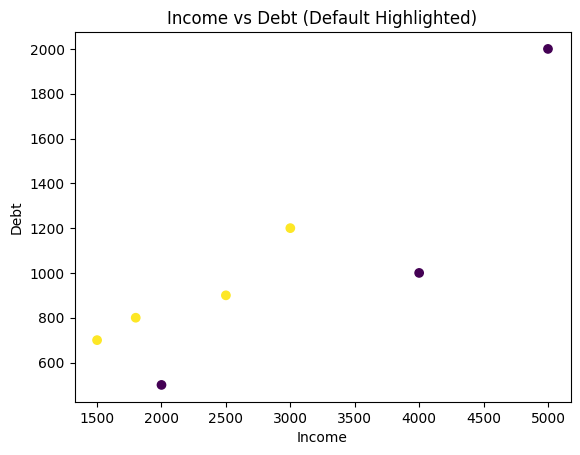

In [ ]:
plt.scatter(df["income"], df["debt"], c=df["default"])
plt.xlabel("Income")
plt.ylabel("Debt")
plt.title("Income vs Debt (Default Highlighted)")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

X = df[["income","debt","debt_to_income"]]
y = df["default"]

model = LogisticRegression()
model.fit(X, y)

model.predict(X)

array([0, 1, 1, 0, 1, 1, 0])

In [ ]:
model.coef_

array([[-4.94377711e-02,  9.79017187e-02,  6.89206514e-05]])

In [ ]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(url)
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


## Conclusion

This project analyzes borrower risk using debt-to-income ratio and logistic regression. Results suggest that higher leverage significantly increases default probability.